# 04 — Full Aero Characterisation

Combine coast-down fits (notebook 02) and ClA estimate (notebook 03) to produce final CdA, Crr, and DRS drag-delta values with Monte Carlo uncertainty.

In [1]:
import sys
sys.path.insert(0, '..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.aero_params import aggregate_results, extract_crr_and_composite, compute_CdA
from src.uncertainty import propagate_uncertainty, drs_delta_uncertainty

G = 9.81

## Load saved results from notebooks 02 and 03

In [2]:
with open('../results/fit_results.pkl', 'rb') as f:
    fit_data = pickle.load(f)

all_results = fit_data['results']
rho = fit_data['rho']
driver = fit_data['driver']

with open('../results/ClA_estimate.pkl', 'rb') as f:
    cla_data = pickle.load(f)

ClA = cla_data['ClA']
ClA_std = cla_data['ClA_std']

print(f'Driver: {driver}')
print(f'ρ = {rho:.4f} kg/m³')
print(f'Total fit results: {len(all_results)}')
print(f'ClA = {ClA:.3f} ± {ClA_std:.3f} m²')

Driver: 14
ρ = 1.1343 kg/m³
Total fit results: 14
ClA = 3.358 ± 0.649 m²


## Aggregate aero parameters

In [3]:
params = aggregate_results(all_results, rho, ClA, ClA_std)

print('\n=== Aero Parameter Summary ===')
print(f'Crr          = {params.Crr:.4f} ± {params.Crr_std:.4f}   (expected 0.015–0.020)')
print(f'ClA          = {params.ClA:.3f} ± {params.ClA_std:.3f} m²  (expected 2.5–3.5)')
print(f'CdA (closed) = {params.CdA:.3f} ± {params.CdA_std:.3f} m²  (expected 0.8–1.0)')
print(f'CdA (open)   = {params.CdA_drs_open:.3f} ± {params.CdA_drs_open_std:.3f} m²')
print(f'ΔCDA (DRS)   = {params.delta_CdA:.3f} ± {params.delta_CdA_std:.3f} m²  (expected -0.5 to -0.8)')


=== Aero Parameter Summary ===
Crr          = 0.0131 ± 0.0001   (expected 0.015–0.020)
ClA          = 3.358 ± 0.649 m²  (expected 2.5–3.5)
CdA (closed) = 1.366 ± 0.009 m²  (expected 0.8–1.0)
CdA (open)   = nan ± nan m²
ΔCDA (DRS)   = nan ± nan m²  (expected -0.5 to -0.8)


## Monte Carlo uncertainty propagation

In [4]:
results_closed = [r for r in all_results if not r.drs_open]
results_open   = [r for r in all_results if r.drs_open]

mc_closed = propagate_uncertainty(results_closed, rho, ClA, ClA_std)
mc_open   = propagate_uncertainty(results_open,   rho, ClA, ClA_std)

print('\n=== Monte Carlo Results ===')
print(f'CdA (DRS closed): {mc_closed.CdA_mean:.3f} ± {mc_closed.CdA_std:.3f} m²'
      f'  [5th–95th: {mc_closed.CdA_p5:.3f}–{mc_closed.CdA_p95:.3f}]')

if results_open:
    delta_mean, delta_std = drs_delta_uncertainty(mc_closed, mc_open)
    print(f'CdA (DRS open):   {mc_open.CdA_mean:.3f} ± {mc_open.CdA_std:.3f} m²')
    print(f'ΔCDA (DRS open):  {delta_mean:.3f} ± {delta_std:.3f} m²')
else:
    delta_mean, delta_std = float('nan'), float('nan')
    print('CdA (DRS open):   no DRS-open segments in dataset — delta cannot be computed')


=== Monte Carlo Results ===
CdA (DRS closed): 1.366 ± 0.009 m²  [5th–95th: 1.351–1.381]
CdA (DRS open):   no DRS-open segments in dataset — delta cannot be computed


## CdA vs lap number — fuel load trend

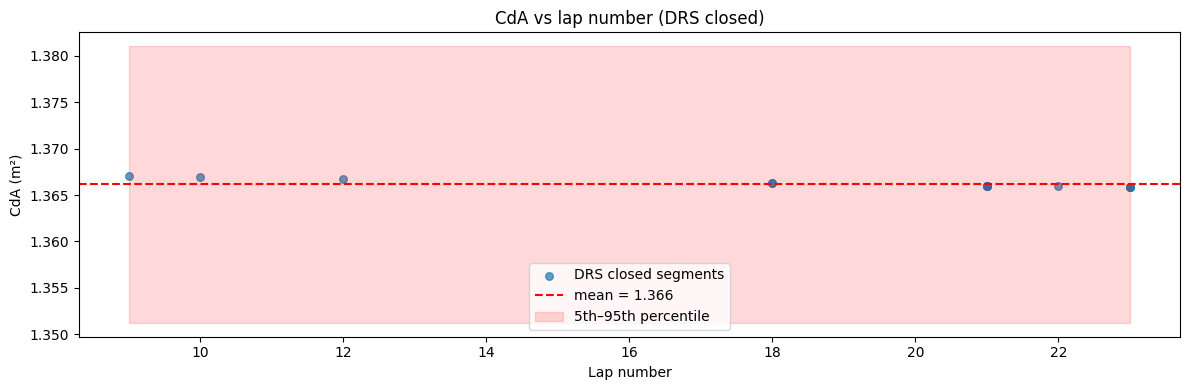

In [5]:
closed_results = [r for r in all_results if not r.drs_open]
laps_c = [r.lap_number for r in closed_results]
Crr_c  = [r.beta / (r.m * G) for r in closed_results]
comp_c = [2.0 * r.alpha / rho for r in closed_results]
CdA_c  = [compute_CdA(comp, crr, ClA) for comp, crr in zip(comp_c, Crr_c)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(laps_c, CdA_c, alpha=0.7, s=30, label='DRS closed segments')
ax.axhline(mc_closed.CdA_mean, color='r', linestyle='--', label=f'mean = {mc_closed.CdA_mean:.3f}')
ax.fill_between(
    [min(laps_c), max(laps_c)],
    mc_closed.CdA_p5, mc_closed.CdA_p95,
    alpha=0.15, color='r', label='5th–95th percentile'
)
ax.set_xlabel('Lap number')
ax.set_ylabel('CdA (m²)')
ax.set_title('CdA vs lap number (DRS closed)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/04_CdA_vs_lap.png', dpi=150)
plt.show()

## DRS drag delta — bar chart with uncertainty

In [6]:
if not results_open:
    print('No DRS-open segments — skipping DRS delta plot.')
else:
    labels = ['DRS closed', 'DRS open']
    means  = [mc_closed.CdA_mean, mc_open.CdA_mean]
    stds   = [mc_closed.CdA_std,  mc_open.CdA_std]
    colors = ['steelblue', 'tomato']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    bars = ax.bar(labels, means, yerr=stds, capsize=8, color=colors, width=0.5)
    ax.set_ylabel('CdA (m²)')
    ax.set_title('CdA by DRS state')
    for bar, val, err in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, val + err + 0.01,
                f'{val:.3f}±{err:.3f}', ha='center', va='bottom', fontsize=9)

    ax = axes[1]
    rng = np.random.default_rng(99)
    delta_samples = (
        rng.normal(mc_open.CdA_mean, mc_open.CdA_std, 10000) -
        rng.normal(mc_closed.CdA_mean, mc_closed.CdA_std, 10000)
    )
    ax.hist(delta_samples, bins=50, edgecolor='black', color='orchid')
    ax.axvline(delta_mean, color='r', linestyle='--', label=f'mean = {delta_mean:.3f}')
    ax.axvline(0, color='k', linestyle=':', label='zero')
    ax.set_xlabel('ΔCDA_DRS = CdA_open − CdA_closed (m²)')
    ax.set_ylabel('count')
    ax.set_title('MC distribution of DRS drag delta')
    ax.legend()

    plt.tight_layout()
    plt.savefig('../results/figures/04_DRS_delta.png', dpi=150)
    plt.show()

    print(f'\nDRS drag delta: {delta_mean:.3f} ± {delta_std:.3f} m²')
    print(f'Expected: -0.5 to -0.8 m²')

No DRS-open segments — skipping DRS delta plot.


## Sanity check table

In [7]:
checks = [
    ('Crr',              mc_closed.Crr_mean, mc_closed.Crr_std, 0.015, 0.020),
    ('CdA (DRS closed)', mc_closed.CdA_mean, mc_closed.CdA_std, 0.80,  1.00),
    ('ClA',              ClA,                ClA_std,            2.50,  3.50),
]

print(f'{"Quantity":<28} {"Value":>8}  {"±":>6}  {"Expected":>15}  {"Pass?"}')
print('-' * 75)
for name, val, err, lo, hi in checks:
    in_range = lo <= val <= hi
    flag = '✓' if in_range else '✗  ← CHECK'
    print(f'{name:<28} {val:8.3f}  {err:6.3f}  [{lo:.2f}, {hi:.2f}]     {flag}')

if np.isfinite(delta_mean):
    in_range = -0.80 <= delta_mean <= -0.50
    flag = '✓' if in_range else '✗  ← CHECK'
    print(f'{"ΔCDA (DRS open−closed)":<28} {delta_mean:8.3f}  {delta_std:6.3f}  [-0.80, -0.50]     {flag}')
else:
    print(f'{"ΔCDA (DRS open−closed)":<28} {"n/a":>8}  {"—":>6}  [-0.80, -0.50]     ✗  no DRS-open data')

Quantity                        Value       ±         Expected  Pass?
---------------------------------------------------------------------------
Crr                             0.013   0.000  [0.01, 0.02]     ✗  ← CHECK
CdA (DRS closed)                1.366   0.009  [0.80, 1.00]     ✗  ← CHECK
ClA                             3.358   0.649  [2.50, 3.50]     ✓
ΔCDA (DRS open−closed)            n/a       —  [-0.80, -0.50]     ✗  no DRS-open data
